# Projet 04 - RAG & LLM : L'assistant virtuel de l'Hôtel Le Belvédère

*Temps estimé : 60 minutes*

Bienvenue dans le quatrième projet du cahier de vacances Machine Learnia !


<div align="center">
<img src="./image.png" alt="ouvrir dans VSCode pour voir l'image" width="800"/>
</div>

Ton téléphone affiche un numéro inconnu. C'est Marc, le propriétaire de l'Hôtel Le Belvédère, au bord du lac d'Annecy. Léa lui a donné ton contact après lui avoir raconté l'histoire du Tour de France 2027. « J'ai un problème, et j'espère que tu peux m'aider », annonce-t-il d'une voix fatiguée. En pleine saison estivale, une bonne partie de son équipe de réception est clouée au lit par un virus qui tourne, et les deux personnes qui tiennent le comptoir croulent sous les appels et les emails : horaires d'arrivée, prix des chambres, présence d'un spa, chiens acceptés ou non, wifi... « On m'a parlé d'intelligence artificielle qui répond toute seule aux clients, un peu comme sur Booking. Ça t'intéresse de m'aider à mettre ça en place ? »

Tu acceptes, avec une condition posée par Marc lui-même : « Surtout, je ne veux pas qu'elle invente des choses. Imagine qu'elle promette un room service 24h/24 qu'on n'a pas, ou un tarif inventé, ça me retombe dessus. » Le problème est bien posé : un modèle de langage générique ne connaît rien de l'Hôtel Le Belvédère, il ne peut donc que deviner, ou pire, halluciner une réponse plausible mais fausse. La solution s'appelle le RAG (Retrieval-Augmented Generation) : donner au modèle un accès à la vraie documentation de l'hôtel, et lui interdire de répondre en dehors de ce qu'elle contient.

Dans ce projet, tu vas construire cet assistant pas à pas, en trois actes. D'abord, tu interrogeras un modèle de langage « tout nu », et tu le prendras en flagrant délit d'invention. Ensuite, Marc t'enverra sa documentation, cinq fichiers PDF, que tu apprendras à lire en Python et à glisser en entier dans le prompt : les réponses s'amélioreront nettement, mais pas complètement. Enfin, tu construiras un vrai RAG, qui ne donne au modèle que les passages pertinents : des réponses justes, des sources citées, et un honnête « je ne sais pas » quand la documentation ne dit rien. Chaque étape est guidée de bout en bout : tu n'auras jamais plus de trois ou quatre lignes de code à écrire à la fois.

### Les outils du jour : Hugging Face, pypdf et sentence-transformers

Jusqu'ici, tu as entraîné tes propres modèles sur des données numériques ou géographiques (les matchs de foot, les villages du Tour de France). Cette semaine, changement complet de terrain : on manipule du texte, et on utilise des modèles déjà entraînés par d'autres, sur des quantités de données qu'on ne pourrait jamais réunir soi-même. Ce sont des modèles pré-entraînés, et [Hugging Face](https://huggingface.co) en héberge plus d'un million, téléchargeables gratuitement en quelques lignes de code.

Trois librairies nous accompagnent :

- `transformers` (par Hugging Face) : pour télécharger un LLM et le faire tourner sur ta machine, en une ligne.
- `pypdf` : pour extraire le texte des documents PDF de Marc.
- `sentence-transformers` : pour transformer des textes en vecteurs numériques (les fameux *embeddings* de la partie 3), en une ligne aussi.

Rassure-toi : on ne rentrera pas dans les entrailles de ces librairies. Chaque fois qu'un code est technique, il est fourni et commenté ; ce que tu écriras toi-même, c'est la logique de l'assistant.

### Au fait... pourquoi un RAG, alors que ChatGPT existe ?

Question légitime, à se poser avant d'écrire la moindre ligne de code. Les grands LLM accessibles par API payante (Claude d'Anthropic, GPT d'OpenAI, Gemini de Google) ont aujourd'hui des fenêtres de contexte gigantesques : 200 000 tokens, parfois plus d'un million. (Le token est l'unité de texte que lisent et écrivent les LLM : un petit morceau de mot, souvent moins qu'un mot entier. Un million de tokens, c'est plusieurs livres entiers.) La documentation complète d'un petit hôtel y tient sans effort. Pour Marc, on pourrait donc simplement tout coller dans le prompt à chaque question, et un RAG ne serait, en soi, pas nécessaire. C'est d'ailleurs exactement ce qu'on fera en partie 2, et ça marchera... plutôt pas mal.

Mais cette approche « je mets tout dans le prompt » ne survit pas au passage à l'échelle de la vraie vie des entreprises, pour trois raisons :

1. **Le volume** : une banque, un industriel ou une administration possède des milliers, parfois des millions de documents internes. Même une fenêtre d'un million de tokens déborde très vite.
2. **Le coût et la vitesse** : les API facturent au token envoyé. Renvoyer l'intégralité de la documentation à chaque question, des milliers de fois par jour, coûte une fortune, et chaque réponse est ralentie par la lecture d'un contexte immense.
3. **La confidentialité** : mettre ses documents dans le prompt, c'est les envoyer aux serveurs de ces entreprises américaines. Beaucoup d'organisations (hôpitaux, banques, industries sensibles...) s'y refusent, et font tourner des modèles open source plus petits sur leurs propres machines, avec des fenêtres de contexte bien plus modestes.

C'est pourquoi l'approche RAG + embeddings reste un incontournable de l'IA en entreprise, et le restera sûrement encore très longtemps. Voici donc le programme du jour, en trois actes :

1. **Le LLM tout seul** : on l'interroge sur l'hôtel, et on le prend en flagrant délit d'hallucination.
2. **Tout dans le prompt** : on lui fournit la documentation complète à chaque question. Nettement mieux, mais lent, et pas infaillible.
3. **Le RAG** : on ne lui donne que les passages pertinents, retrouvés automatiquement grâce aux embeddings. Précis, rapide, honnête.

# Avant tout : Import de nos librairies

Trois nouvelles librairies rejoignent l'environnement cette semaine : `transformers`, `sentence-transformers` et `pypdf` (ainsi que `torch`, le moteur de calcul sur lequel s'appuient les deux premières). Pour les ajouter à ton environnement, tu peux utiliser la commande suivante :

```bash
uv add transformers torch sentence-transformers pypdf ipywidgets matplotlib scikit-learn
```

(`ipywidgets` sert uniquement à afficher des barres de progression pendant le téléchargement des modèles ; `matplotlib` et `scikit-learn`, tes vieux compagnons des projets précédents, serviront pour une visualisation bonus en partie 3.)

À la première exécution, deux modèles seront téléchargés depuis Hugging Face (environ 1,5 Go au total) : ils sont mis en cache sur ta machine, ce téléchargement ne se fait qu'une seule fois.

Comme aux projets précédents, un fichier `utils.py` accompagne le notebook : il contient une fonction d'affichage, `print_chat`, pour présenter joliment les échanges avec l'assistant. N'hésite pas à y jeter un œil.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import transformers
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from transformers import pipeline

from utils import print_chat

transformers.logging.set_verbosity_error()  # masque les avertissements techniques, pour garder un affichage lisible

# Partie 1 - La preuve par l'exemple : quand un LLM invente

Avant de construire quoi que ce soit, vérifions l'inquiétude de Marc. On va charger un modèle de langage généraliste et lui poser directement des questions sur l'hôtel, sans lui donner la moindre information. Le modèle utilisé est `Qwen/Qwen2.5-0.5B-Instruct`, un petit modèle conversationnel (environ 500 millions de paramètres) entraîné pour suivre des instructions et discuter en plusieurs langues, dont le français. Il est volontairement petit : assez léger pour tourner sur un ordinateur portable en quelques secondes, ce qui est parfait pour apprendre. Un modèle plus gros donnerait de meilleures réponses, mais les principes de ce projet resteraient exactement les mêmes.

Pour l'utiliser, `transformers` propose l'objet `pipeline` : on lui donne le nom d'une tâche (ici `"text-generation"` : je te donne du texte, tu m'en génères) et le nom d'un modèle, et il s'occupe de tout télécharger et de tout assembler.

### Étape 1 : charger le modèle de génération

Charge le pipeline de génération de texte avec le modèle `"Qwen/Qwen2.5-0.5B-Instruct"`, et stocke-le dans la variable `generator`.

> Indice : `generator = pipeline("text-generation", model=....)`.

In [2]:
### START CODE HERE ###

generator = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct")

### END CODE HERE ###

print(type(generator).__name__, "-", generator.task)

assert generator.task == "text-generation", "La tâche du pipeline devrait être text-generation"
print("Exercice validé !")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

TextGenerationPipeline - text-generation
Exercice validé !


Pour discuter avec ce genre de modèle, on lui envoie une conversation : une liste de messages, chacun avec un rôle (`"user"` pour nous, `"assistant"` pour lui) et un contenu. Le modèle génère alors le message suivant de la conversation. La syntaxe exacte étant un peu verbeuse, voici une petite fonction toute prête, `ask_llm` : tu lui donnes un texte, elle te rend la réponse du modèle.

Deux détails dans son code : `max_new_tokens=80` limite la longueur de la réponse à 80 tokens, soit grosso modo une soixantaine de mots (assez pour une ou deux phrases, et le temps de calcul reste raisonnable ; il arrivera donc qu'une réponse soit coupée en plein élan, c'est normal), et `do_sample=False` rend le modèle déterministe : à question identique, réponse identique, ce qui est pratique pour un projet guidé.

In [3]:
def ask_llm(prompt):
    """
    Send one message to the LLM and return its answer.

    Arguments:
    prompt -- the message to send, as a string

    Returns:
    answer -- the text generated by the model
    """
    conversation = generator([{"role": "user", "content": prompt}], max_new_tokens=80, do_sample=False)
    answer = conversation[0]["generated_text"][-1]["content"]
    return answer


print(ask_llm("Bonjour ! Qui es-tu, en une phrase ?"))

Je suis Qwen, un modèle de langage créé par Alibaba Cloud. Je suis disponible pour aider avec des questions ou des tâches spécifiques. Comment puis-je vous aider aujourd'hui ?


Le modèle répond, il parle français, tout fonctionne. Maintenant, les questions qui fâchent : interrogeons-le sur l'Hôtel Le Belvédère, sans lui donner la moindre information à son sujet.

In [4]:
questions_test = [
    "A quelle heure puis-je faire mon check-in a l'Hotel Le Belvedere ?",
    "Est-ce qu'il y a un spa a l'Hotel Le Belvedere ?",
]

for question in questions_test:
    print_chat(question, ask_llm(question))

Client   : A quelle heure puis-je faire mon check-in a l'Hotel Le Belvedere ?
Assistant: Pour effectuer votre check-in à l'hôtel Le Belvedere, vous devrez suivre les instructions de la plateforme d'hébergement. Voici comment vous pouvez procéder :

1. Vérifiez le site web officiel ou le site Web du hotel pour obtenir les informations nécessaires.

2. Assurez-vous que vous avez bien rempli tous les
--------------------------------------------------------------------------------
Client   : Est-ce qu'il y a un spa a l'Hotel Le Belvedere ?
Assistant: Oui, il existe un spa à l'hôtel Le Belvedere. Le Belvedere est une propriété de luxe située dans le centre-ville de Paris, France. Il s'agit d'un hôtel de 5 étoiles qui offre des services de qualité pour les clients.

Le spa de Le Belvedere comprend plusieurs atouts :

1. Une piscine privée
--------------------------------------------------------------------------------


Voilà, mot pour mot, ce que redoutait Marc. À la première question, le modèle part dans un tutoriel générique sur « la plateforme d'hébergement », qui n'a rien à voir avec notre hôtel. À la seconde, il affirme avec aplomb que l'Hôtel Le Belvédère est « une propriété de luxe située dans le centre-ville de Paris », un « hôtel de 5 étoiles » avec spa et piscine. Le plus troublant, c'est que tout n'est pas faux : l'hôtel a bel et bien un spa, tu le verras dans la documentation. Mais c'est un pur coup de chance : les hôtels au bord d'un lac ont souvent un spa, alors le modèle a parié. Paris et les 5 étoiles, en revanche, sont inventés de toutes pièces : l'hôtel est à Annecy, et personne ne lui a jamais parlé d'étoiles. C'est ça, une hallucination : le modèle devine, avec exactement la même assurance quand il tombe juste que quand il se trompe. Et comme rien ne permet de distinguer la devinette chanceuse de l'invention pure, aucune de ses réponses n'est utilisable.

Ce comportement est logique. Le modèle a été entraîné sur des données publiques d'internet, où l'hôtel de Marc n'apparaît nulle part. Interrogé quand même, il complète avec ce qui lui semble statistiquement plausible pour un hôtel qui porte ce nom, sans aucun moyen de distinguer ce qu'il sait de ce qu'il invente. La conclusion s'impose : il faut lui donner les vraies informations de l'hôtel. Passons un coup de fil à Marc.

# Partie 2 - Les documents de Marc : tout mettre dans le prompt

Tu envoies un message à Marc : « Il me faudrait toute la documentation de l'hôtel. » Sa réponse arrive dix minutes plus tard : cinq fichiers PDF en pièces jointes, rédigés par l'équipe de la réception au fil des années. Pas de belle base de données, pas de fichier Excel bien rangé : des PDF, faits pour être imprimés et lus par des humains. C'est ça, la vraie vie des projets de data : les données arrivent rarement dans le format dont on rêve, et c'est à nous de nous en débrouiller.

Les cinq fichiers t'attendent dans le dossier `data/` du projet. Commençons par vérifier qu'ils sont bien là :

In [5]:
pdf_paths = sorted(Path("data").glob("*.pdf"))

for path in pdf_paths:
    print(path.name)

assert len(pdf_paths) == 5, f"5 fichiers PDF attendus dans data/, {len(pdf_paths)} trouvés"
print("\nLes 5 documents de Marc sont bien là !")

activites_et_evenements.pdf
chambres_et_tarifs.pdf
familles_animaux_accessibilite.pdf
informations_pratiques.pdf
restaurant_et_bien_etre.pdf

Les 5 documents de Marc sont bien là !


Un PDF n'est pas un fichier texte : impossible de l'ouvrir avec un simple `open()`. La librairie `pypdf` fait le travail pour nous : `PdfReader(chemin)` ouvre le document, `reader.pages` donne la liste de ses pages, et chaque page sait extraire son propre texte grâce à sa méthode `.extract_text()`.

Ouvrons le premier document pour voir :

In [6]:
reader = PdfReader("data/informations_pratiques.pdf")

print(f"informations_pratiques.pdf contient {len(reader.pages)} pages")

informations_pratiques.pdf contient 4 pages


### Étape 2 : extraire le texte d'une page

À toi de jouer : extrais le texte de la première page du document (`reader.pages[0]`), stocke-le dans `page_text`, puis regarde ce qu'il contient.

> Indice : la méthode s'appelle `.extract_text()`, sans argument.

In [7]:
### START CODE HERE ###

page_text = reader.pages[0].extract_text()

### END CODE HERE ###

print(page_text)

assert isinstance(page_text, str) and len(page_text) > 100, "page_text devrait contenir le texte de la première page"
assert "réception" in page_text.lower(), "La première page devrait parler de la réception"
print("\nExercice validé !")

Horaires de la réception
La réception de l'Hôtel Le Belvédère est ouverte tous les jours de 7h à 22h. En dehors de ces horaires, un
numéro d'astreinte est affiché à l'entrée pour toute urgence. Le check-in démarre à 15h et le check-out se fait
avant 11h. Un départ tardif jusqu'à 13h peut être accordé gratuitement selon la disponibilité des chambres, il
suffit de le demander la veille à la réception. Une arrivée tardive après 22h doit être annoncée à l'avance par
téléphone ou email pour que le personnel de nuit prépare la remise des clés.
Hôtel Le Belvédère - 12 avenue du Lac, 74000 Annecy - Documentation interne - page 1

Exercice validé !


Regarde bien le résultat : la première ligne est le titre de la rubrique (« Horaires de la réception »), et la dernière ligne est le pied de page du document (adresse de l'hôtel, numéro de page), qui se répète sur toutes les pages et ne nous apprend rien. Données réelles, nettoyage obligatoire : c'est une constante du métier, et les PDF sont réputés pour ça.

Le code fourni ci-dessous applique la recette à toutes les pages des cinq PDF. Chaque page de ces documents correspond à une rubrique de la documentation (les horaires, le wifi, les tarifs...). Pour chacune, on récupère le nom du fichier source, le titre de la rubrique (la première ligne) et le texte de la rubrique (tout sauf la ligne de titre et le pied de page). Résultat : un DataFrame `pages`, avec une ligne par rubrique.

In [8]:
rows = []
for path in pdf_paths:
    reader = PdfReader(path)
    for page in reader.pages:
        lines = page.extract_text().split("\n")
        rows.append({
            "source": path.name,             # le fichier PDF d'origine
            "title": lines[0],               # la première ligne de la page est le titre de la rubrique
            "text": "\n".join(lines[1:-1]),  # le texte, sans la ligne de titre ni le pied de page
        })

pages = pd.DataFrame(rows)
print(f"{len(pages)} rubriques extraites des {len(pdf_paths)} PDF")
display(pages)

assert len(pages) == 15, f"15 rubriques attendues, {len(pages)} trouvées"
print("Documentation chargée !")

15 rubriques extraites des 5 PDF


,source,title,text
0,activites_et_evenements.pdf,Activités et alentours,L'hôtel loue des vélos électriques à l'accueil...
1,activites_et_evenements.pdf,Séminaires et événements,"L'hôtel dispose de deux salles de séminaire, p..."
2,chambres_et_tarifs.pdf,Chambres et tarifs,L'hôtel propose 42 chambres réparties en quatr...
3,chambres_et_tarifs.pdf,Politique d'annulation et de paiement,L'annulation est gratuite jusqu'à 48h avant la...
4,chambres_et_tarifs.pdf,Climatisation et confort des chambres,Toutes les chambres de l'hôtel sont climatisée...
5,familles_animaux_accessibilite.pdf,Familles et enfants,Les lits bébé et les chaises hautes sont fourn...
6,familles_animaux_accessibilite.pdf,Animaux domestiques,Les animaux domestiques de moins de 10 kg sont...
7,familles_animaux_accessibilite.pdf,Accessibilité PMR,L'hôtel dispose de 4 chambres adaptées aux per...
8,informations_pratiques.pdf,Horaires de la réception,La réception de l'Hôtel Le Belvédère est ouver...
9,informations_pratiques.pdf,Wifi et connexion internet,Le wifi est gratuit et illimité dans toutes le...


Documentation chargée !


### Étape 3 : mettre la documentation en forme (Markdown)

Assemblons maintenant ces rubriques en un seul grand texte, prêt à être glissé dans le prompt. Plutôt que de tout coller brutalement bout à bout, on va le structurer au format Markdown, le langage de mise en forme que tu utilises déjà dans les cellules de ce notebook : chaque rubrique devient une section, avec son titre précédé de `## `. Les LLM ont lu énormément de Markdown pendant leur entraînement : un contexte bien structuré, avec des titres clairs, les aide vraiment à s'y retrouver.

Construis d'abord une nouvelle colonne `section` du DataFrame (pour chaque rubrique : son titre précédé de `## `, une ligne vide, puis son texte), puis assemble toutes les sections dans `context_md`, avec une ligne vide entre chacune. On garde la colonne `section` précieusement : elle resservira telle quelle dans la partie 3.

> Indice : ici, on effectue un travail sur les "strings". Utiliser un `.join()` sera utile ! et pour rappel, `"\n"` est le caractère « retour à la ligne ».

In [9]:
### START CODE HERE ###

pages["section"] = pages["title"].str.split(" - ").str[0]
context_md = "\n\n".join([f"## {row['title']}\n{row['text']}" for _, row in pages.iterrows()])

### END CODE HERE ###

print(context_md[:450])
print("[...]")
print(f"\nLongueur totale de la documentation : {len(context_md.split())} mots")

assert "section" in pages.columns, "Il manque la colonne section dans pages"
assert context_md.count("## ") == 15, "Le contexte devrait contenir les 15 titres de rubriques"
assert "## Spa et bien-être" in context_md, "Chaque rubrique devrait apparaître comme un titre markdown"
print("Exercice validé !")

## Activités et alentours
L'hôtel loue des vélos électriques à l'accueil pour 20 euros la demi-journée. Un ponton privé permet de
pratiquer le paddle et le kayak gratuitement pour les clients, de juin à septembre. Le sentier de randonnée du
Semnoz est accessible en 20 minutes de marche depuis l'hôtel. Le marché d'Annecy se tient le jeudi, le
vendredi et le dimanche matin dans la vieille ville, à environ 10 minutes à pied. Les canaux et la vieille
[...]

Longueur totale de la documentation : 1415 mots
Exercice validé !


### Étape 4 : construire le prompt

Dernier ingrédient avant le test : le prompt. Il rassemble quatre choses, dans cet ordre : le rôle de l'assistant, la documentation (le contexte), la question du client, et la consigne de Marc, celle qui interdit d'inventer. Le rôle et la consigne sont fournis ci-dessous dans les variables `ROLE` et `CONSIGNE` : la consigne, en particulier, est ce qui protège des hallucinations, en offrant au modèle une porte de sortie honnête quand il ne sait pas.

Complète `build_prompt` avec une f-string qui assemble les quatre morceaux. Un point important : notre modèle étant déterministe, tes sorties ne seront identiques à celles de ce notebook que si ton prompt est identique au caractère près (l'assert de validation y veillera).

> Voici notre prompt: `f"{ROLE}\n\n{context}\n\nQuestion d'un client : {question}\n{CONSIGNE}"`

In [10]:
ROLE = (
    "Tu es l'assistant virtuel de l'Hôtel Le Belvédère, au bord du lac d'Annecy.\n"
    "Voici la documentation officielle de l'hôtel :"
)

CONSIGNE = (
    "Réponds en une ou deux phrases, uniquement à partir des informations "
    "de la documentation ci-dessus. Si l'information ne s'y trouve pas, réponds exactement : "
    '"Je ne sais pas, je vous invite à contacter la réception."'
)


def build_prompt(context, question):
    """
    Build the prompt sent to the LLM from a context and a question.

    Arguments:
    context -- the documentation the answer must be based on, as a string
    question -- the client's question, as a string

    Returns:
    prompt -- the full prompt, as a string
    """

    ### START CODE HERE ###

    prompt = f"{ROLE}\n\n{context}\n\nQuestion d'un client : {question}\n{CONSIGNE}"


    ### END CODE HERE ###

    return prompt


test_prompt = build_prompt("## Piscine\n\nLa piscine est ouverte de 8h à 20h.", "La piscine est-elle chauffée ?")
print(test_prompt)

prompt_attendu = (
    f"{ROLE}\n\n## Piscine\n\nLa piscine est ouverte de 8h à 20h.\n\n"
    f"Question d'un client : La piscine est-elle chauffée ?\n{CONSIGNE}"
)
assert test_prompt == prompt_attendu, \
    "Le prompt doit suivre exactement le modèle (ROLE, ligne vide, contexte, ligne vide, question, consigne) : " \
    "c'est la garantie que tes résultats seront identiques à ceux du notebook"
print("\nExercice validé !")

Tu es l'assistant virtuel de l'Hôtel Le Belvédère, au bord du lac d'Annecy.
Voici la documentation officielle de l'hôtel :

## Piscine

La piscine est ouverte de 8h à 20h.

Question d'un client : La piscine est-elle chauffée ?
Réponds en une ou deux phrases, uniquement à partir des informations de la documentation ci-dessus. Si l'information ne s'y trouve pas, réponds exactement : "Je ne sais pas, je vous invite à contacter la réception."

Exercice validé !


Tout est prêt pour le grand test de l'approche « tout dans le prompt ». Quatre questions : trois dont la réponse est dans la documentation, et une question piège sur un sujet qui n'y figure pas (les paiements en Bitcoin), pour vérifier que l'assistant sait dire « je ne sais pas » au lieu d'inventer. À chaque question, c'est l'intégralité de la documentation qui part dans le prompt, et le temps de réponse s'en ressent : le modèle doit d'abord « lire » les quelque 1 400 mots du contexte avant d'écrire le moindre mot.

Complete la boucle `for` ci-dessous pour faire tourner le llm.

In [11]:
questions_hotel = [
    "A quelle heure commence le check-in ?",
    "Le wifi est-il gratuit ?",
    "Combien coute une chambre Classique en basse saison ?",
    "Est-ce que vous acceptez les paiements en Bitcoin ?",
]

start = time.time()
for question in questions_hotel:
    ### START CODE HERE ###

    for question in questions_hotel:
        prompt = build_prompt(context_md, question)
        answer = ask_llm(prompt)
        print_chat(question, answer)
    
    # construire le prompt
    # afficher la réponse du llm a l'écran
    
    ### END CODE HERE ###

print(f"Temps total : {time.time() - start:.0f} secondes pour {len(questions_hotel)} questions")

Client   : A quelle heure commence le check-in ?
Assistant: La réception de l'Hôtel Le Belvédère est ouverte tous les jours de 7h à 22h.
--------------------------------------------------------------------------------
Client   : Le wifi est-il gratuit ?
Assistant: Je ne sais pas, je vous invite à contacter la réception.
--------------------------------------------------------------------------------
Client   : Combien coute une chambre Classique en basse saison ?
Assistant: Une chambre Classique en basse saison coûte 120 euros par nuit.
--------------------------------------------------------------------------------
Client   : Est-ce que vous acceptez les paiements en Bitcoin ?
Assistant: Je ne sais pas, je vous invite à contacter la réception.
--------------------------------------------------------------------------------
Client   : A quelle heure commence le check-in ?
Assistant: La réception de l'Hôtel Le Belvédère est ouverte tous les jours de 7h à 22h.
---------------------------

Le progrès est réel : plus aucune trace de l'hôtel parisien imaginaire, la chambre Classique est au bon prix (120 euros la nuit, exactement ce que dit la documentation), et la question piège sur le Bitcoin reçoit précisément la réponse honnête que notre consigne exigeait. Mais regarde de plus près, car deux réponses clochent :

- Au check-in demandé, le modèle répond... les horaires d'ouverture de la réception (7h à 22h). La bonne information (« le check-in démarre à 15h ») était pourtant dans le contexte, deux phrases plus loin : noyé au milieu de 1 400 mots, le modèle a attrapé la mauvaise phrase de la bonne rubrique.
- Sur le wifi, il répond carrément « je ne sais pas », alors que la rubrique wifi est là, sous ses yeux, et commence par « Le wifi est gratuit ». Trop d'informations d'un coup, et notre petit modèle passe à côté.

Et il y a le temps de calcul : plusieurs minutes pour quatre questions, car le modèle doit relire l'intégralité de la documentation avant chaque réponse. Transpose maintenant tout cela à la vraie vie d'une grande entreprise, comme on l'annonçait en introduction : des milliers de documents au lieu de 15 rubriques (le contexte déborde, même chez les géants du LLM), des milliers de questions par jour (la facture d'API et le temps d'attente explosent, puisqu'on paye au token), et des documents confidentiels qu'on n'a pas toujours le droit d'envoyer sur des serveurs à l'étranger.

Verdict : mieux qu'en partie 1, mais ni fiable ni généralisable. Il est temps d'arrêter de gaver le modèle, et de ne lui donner que ce dont il a besoin.

# Partie 3 - Le RAG : ne donner au modèle que les bonnes pages

Réfléchis à ce que ferait un bon réceptionniste humain avec le classeur de documentation de l'hôtel : pour répondre à une question sur le wifi, il ne relit pas le classeur en entier, il ouvre directement la bonne page. C'est exactement l'idée du RAG (Retrieval-Augmented Generation, « génération augmentée par récupération ») : avant chaque réponse, une étape de recherche retrouve les rubriques pertinentes de la documentation, et seules ces rubriques sont mises dans le prompt.

Question du client → Recherche dans la documentation → les 2-3 rubriques les plus pertinentes → Prompt = mini-contexte + question → LLM → Réponse

Deux mots de vocabulaire, pour parler comme les pros :

- **Les chunks** : dans un vrai système RAG, les documents longs sont d'abord découpés en morceaux de quelques paragraphes, appelés *chunks* (c'est l'étape de *chunking*). Ici, le travail est déjà fait pour nous : la documentation de Marc est organisée en 15 rubriques courtes, une par page, qui sont des chunks tout trouvés.
- **La base de données vectorielle** : en production, les vecteurs de tous les chunks sont stockés dans un index ou une base spécialisée (FAISS, Chroma, Pinecone...), capable de chercher parmi des millions de vecteurs en quelques millisecondes. Avec nos 15 rubriques, un simple tableau `numpy` fera parfaitement l'affaire, et permettra de voir exactement ce qui se passe.

Reste la question centrale : comment une machine « cherche »-t-elle les rubriques pertinentes ? Avec des mots-clés ? Trop fragile : un client demande « acceptez-vous les chiens ? » alors que la documentation parle d'« animaux domestiques », et la recherche par mots-clés ne trouve rien. La réponse moderne s'appelle les embeddings.

### Les embeddings : transformer le sens en nombres

Un embedding est un vecteur de nombres (ici, 384) qui représente le *sens* d'un texte. Le principe est presque magique : deux textes qui veulent dire la même chose ont des vecteurs proches, même s'ils n'ont aucun mot en commun. « Acceptez-vous les chiens ? » et « Animaux domestiques » se retrouvent voisins dans cet espace à 384 dimensions.

La librairie `sentence-transformers` rend ces modèles très simples à utiliser. On prend le modèle `paraphrase-multilingual-MiniLM-L12-v2`, un petit modèle d'embedding entraîné sur des dizaines de langues, dont le français. Ce choix n'est pas anodin : notre documentation est en français, et un modèle d'embedding optimisé uniquement pour l'anglais donnerait de bien moins bons résultats.

### Étape 5 : charger le modèle d'embedding

Charge le modèle `EMBEDDING_MODEL` avec la classe `SentenceTransformer`, et stocke-le dans la variable `embedder`.

> Indice : `SentenceTransformer(EMBEDDING_MODEL)`, tout simplement.

In [14]:
EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

### START CODE HERE ###

embedder = SentenceTransformer(EMBEDDING_MODEL)

### END CODE HERE ###

dimension = embedder.encode(["Bonjour Marc !"]).shape[1]
print(f"Modèle d'embedding chargé : chaque texte devient un vecteur de {dimension} nombres")

assert dimension == 384, "Le modèle devrait produire des vecteurs de dimension 384"
print("Exercice validé !")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modèle d'embedding chargé : chaque texte devient un vecteur de 384 nombres
Exercice validé !


Avant de l'appliquer à la documentation, vérifions sur trois phrases que les embeddings capturent bien le sens. La méthode `.encode()` transforme une liste de textes en une matrice de vecteurs (une ligne par texte). On lui passe `normalize_embeddings=True` pour que tous les vecteurs aient une longueur de 1 : la similarité entre deux textes se calcule alors avec un simple produit scalaire (l'opérateur `@` en Python), qui donne un nombre entre -1 et 1, d'autant plus grand que les textes sont proches en sens. (Les connaisseurs reconnaîtront la similarité cosinus.)

In [15]:
phrases = [
    "La piscine est chauffée à 27 degrés.",
    "Quelle est la température de l'eau de la piscine ?",
    "Le petit-déjeuner est servi jusqu'à 10h30.",
]

vecteurs = embedder.encode(phrases, normalize_embeddings=True)
print("Forme de la matrice de vecteurs :", vecteurs.shape)

print(f"\nSimilarité (piscine / température de l'eau) : {vecteurs[0] @ vecteurs[1]:.3f}")
print(f"Similarité (piscine / petit-déjeuner)        : {vecteurs[0] @ vecteurs[2]:.3f}")

Forme de la matrice de vecteurs : (3, 384)

Similarité (piscine / température de l'eau) : 0.729
Similarité (piscine / petit-déjeuner)        : 0.026


Les deux phrases sur la piscine sont jugées très similaires alors qu'elles ne partagent presque aucun mot (« chauffée à 27 degrés » d'un côté, « température de l'eau » de l'autre), et la phrase sur le petit-déjeuner est loin derrière : les embeddings comparent bien le sens, pas l'orthographe. C'est exactement l'outil qu'il nous fallait.

### Étape 6 : transformer les 15 rubriques en vecteurs

Encode les 15 sections de la documentation (la colonne `section` construite à l'Étape 3 : le titre + le texte de chaque rubrique) dans la matrice `chunk_embeddings`, avec des vecteurs normalisés. On encode ainsi exactement ce qui sera plus tard glissé dans le prompt, titre compris. Le titre aide d'ailleurs la recherche, car il résume le sujet de la rubrique. Cette matrice est notre base de données vectorielle : on la calcule une seule fois, à l'avance ; ensuite, seule la question du client sera encodée à chaque nouvelle demande.

> Indice : `.encode()` attend une liste de textes : `pages["section"].tolist()`. On veut également ajouter normaliser notre embedding avec `normalize_embeddings=True`.

In [16]:
### START CODE HERE ###

chunk_embeddings = embedder.encode(pages["text"].tolist(), normalize_embeddings=True)

### END CODE HERE ###

print(f"Notre base de données vectorielle : {chunk_embeddings.shape[0]} vecteurs de dimension {chunk_embeddings.shape[1]}")

assert chunk_embeddings.shape == (15, 384), f"Forme attendue (15, 384), obtenue {chunk_embeddings.shape}"
print("Exercice validé !")

Notre base de données vectorielle : 15 vecteurs de dimension 384
Exercice validé !


### Étape 7 (bonus) : dessiner la carte des embeddings

Cette étape est optionnelle : rien dans la suite du projet n'en dépend, et tu peux la sauter si tu es pressé. On la fait simplement parce que c'est intéressant : elle permet de *voir* les embeddings de nos rubriques.

Nos 15 vecteurs vivent dans un espace à 384 dimensions, impossible à dessiner. L'algorithme **t-SNE** (fourni par scikit-learn, que tu connais bien maintenant) est une technique de réduction de dimension pensée pour la visualisation : il écrase ces 384 dimensions en 2, en s'efforçant de préserver les proximités. Deux rubriques proches en sens doivent rester voisines sur la carte en 2D.

Utilise la classe `TSNE` pour projeter `chunk_embeddings` en 2 dimensions dans la variable `coords` (le code du graphique, lui, est fourni). Optionnellement, si tu veux obtenir les memes résultats que moi dans la correction, utilise `perplexity=5, random_state=42`

> Voir la documentation sklearn : https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

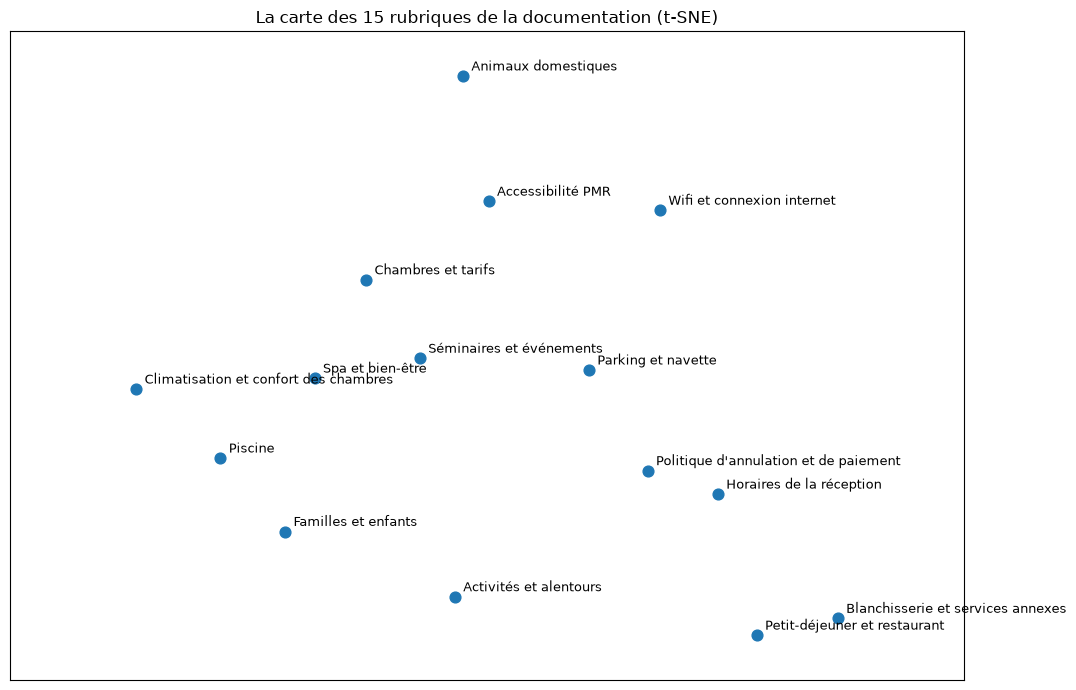

Exercice validé !


In [18]:
### START CODE HERE ###

tsne = TSNE(n_components=2, perplexity=5, learning_rate=10, random_state=42)
coords = tsne.fit_transform(chunk_embeddings)

### END CODE HERE ###

plt.figure(figsize=(11, 7))
plt.scatter(coords[:, 0], coords[:, 1], s=60)
for i, row in pages.iterrows():
    plt.annotate(row["title"], (coords[i, 0], coords[i, 1]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)
plt.title("La carte des 15 rubriques de la documentation (t-SNE)")
plt.xticks([])
plt.yticks([])
plt.margins(x=0.18, y=0.08)
plt.tight_layout()
plt.show()

assert coords.shape == (15, 2), f"Forme attendue (15, 2), obtenue {coords.shape}"
print("Exercice validé !")

Prends une minute pour lire cette carte, elle vaut le détour. Personne n'a dit au modèle que la piscine allait avec les enfants, ou que le petit-déjeuner allait avec la blanchisserie : il a placé les rubriques uniquement d'après le sens de leurs textes, et des quartiers thématiques apparaissent tout seuls. Sur notre exécution, le séjour et le bien-être se regroupent d'un côté (Piscine, Spa et bien-être, Familles et enfants, Climatisation...), les services pratiques du quotidien de l'autre (Petit-déjeuner, Blanchisserie, Horaires de la réception, Politique d'annulation...).

Deux précautions de lecture : les axes n'ont aucune signification, seules les proximités comptent ; et le t-SNE comporte une part d'approximation, si bien que d'une machine à l'autre la carte peut tourner ou se déformer (les regroupements, eux, restent). C'est exactement cette géographie du sens que la recherche de l'étape suivante va exploiter, dans l'espace complet à 384 dimensions dont cette carte n'est qu'un aperçu : la question du client atterrira quelque part dans cet espace, et on ira chercher ses plus proches voisines.

### Étape 8 : la recherche

On en arrive au cœur du RAG. Lorsqu'une question est donnée, trois opérations ont lieu :
- (1) encoder la question en vecteur
- (2) calculer sa similarité avec chacune des 15 rubriques
- (3) garder les `top_k` rubriques les plus proches.

Complète ces trois lignes dansn la fonction `search` (la mise en forme du résultat est fournie).

> Indice : `.encode()` retourne une matrice, même pour un seul texte : d'où le `[0]` pour récupérer notre unique vecteur. Ensuite, `chunk_embeddings @ question_embedding` calcule les 15 similarités d'un seul coup. Enfin, `np.argsort(-similarities)` donne les indices triés du score le plus haut au plus bas, et `[:top_k]` garde les k premiers.

In [19]:
def search(question, top_k=2):
    """
    Retrieve the top_k pages most relevant to a question.

    Arguments:
    question -- the client's question, as a string
    top_k -- number of pages to return

    Returns:
    results -- the top_k rows of pages, with an added score column,
               sorted from most to least relevant
    """

    ### START CODE HERE ###

    question_embedding = embedder.encode([question], normalize_embeddings=True)  # (1)
    similarities = chunk_embeddings @ question_embedding.T  # (2)
    top_indices = np.argsort(similarities.flatten())[::-1][:top_k]  # (3)

    ### END CODE HERE ###

    results = pages.iloc[top_indices].copy()
    results["score"] = similarities[top_indices]
    return results


test_results = search("Est-ce qu'il y a une piscine ?")
display(test_results[["source", "title", "score"]])

assert len(test_results) == 2, "top_k=2 devrait retourner 2 résultats"
assert test_results.iloc[0]["title"] == "Piscine", \
    "La rubrique la plus pertinente pour cette question devrait être « Piscine »"
print("Exercice validé !")

,source,title,score
13,restaurant_et_bien_etre.pdf,Piscine,0.541475
14,restaurant_et_bien_etre.pdf,Spa et bien-être,0.348146


Exercice validé !


La recherche fonctionne : sur une question piscine, la rubrique « Piscine » arrive en tête, avec un score nettement supérieur à ceux des autres rubriques. Remarque au passage que personne n'a programmé de mots-clés : la rubrique a été retrouvée uniquement par proximité de sens.

### Étape 9 : l'assistant complet

Il ne reste qu'à assembler des briques... déjà toutes construites ! `search` retrouve les rubriques pertinentes, leur colonne `section` (Étape 3) fournit le mini-contexte tout mis en forme, `build_prompt` de l'Étape 4 fabrique le prompt (exactement le même qu'en partie 2, avec un contexte simplement plus court), et `ask_llm` génère la réponse. La fonction retourne aussi les rubriques retrouvées : un assistant sérieux cite ses sources.


In [20]:
def answer_question(question, top_k=2):
    """
    Answer a question using the full RAG pipeline.

    Arguments:
    question -- the client's question, as a string
    top_k -- number of pages to retrieve

    Returns:
    answer -- the generated answer, as a string
    retrieved -- the DataFrame of pages used as context
    """

    ### START CODE HERE ###

    retrieved = search(question, top_k=top_k)
    context = "\n\n".join([f"## {row['title']}\n{row['text']}" for _, row in retrieved.iterrows()])
    prompt = build_prompt(context, question)
    answer = ask_llm(prompt)

    ### END CODE HERE ###

    return answer, retrieved


answer, sources = answer_question("A quelle heure ouvre la réception ?")
print_chat("A quelle heure ouvre la réception ?", answer, sources)

assert sources.iloc[0]["title"] == "Horaires de la réception", \
    "La question sur la réception devrait retrouver la rubrique des horaires"
print("Exercice validé !")

Client   : A quelle heure ouvre la réception ?
Sources  : Horaires de la réception (0.74), Politique d'annulation et de paiement (0.61)
Assistant: La réception de l'Hôtel Le Belvédère est ouverte tous les jours de 7h à 22h.
--------------------------------------------------------------------------------
Exercice validé !


Ton assistant RAG est complet ! Le grand final : les mêmes quatre questions qu'en partie 2, question piège comprise.

In [21]:
start = time.time()
for question in questions_hotel:
    answer, sources = answer_question(question)
    print_chat(question, answer, sources)
print(f"Temps total : {time.time() - start:.0f} secondes pour {len(questions_hotel)} questions")

Client   : A quelle heure commence le check-in ?
Sources  : Horaires de la réception (0.60), Politique d'annulation et de paiement (0.53)
Assistant: Le check-in commence à 15h.
--------------------------------------------------------------------------------
Client   : Le wifi est-il gratuit ?
Sources  : Wifi et connexion internet (0.64), Blanchisserie et services annexes (0.25)
Assistant: Le wifi est gratuit et illimité dans toutes les chambres et dans les parties communes de l'hôtel. Il est également possible de recevoir une assistance technique de base ou un routeur de dépannage si nécessaire.
--------------------------------------------------------------------------------
Client   : Combien coute une chambre Classique en basse saison ?
Sources  : Chambres et tarifs (0.55), Climatisation et confort des chambres (0.44)
Assistant: 120 euros
--------------------------------------------------------------------------------
Client   : Est-ce que vous acceptez les paiements en Bitcoin ?
Sou

In [22]:
retrieved = search(questions_hotel[0])
rag_context = "\n\n".join(retrieved["section"])

print(f"Contexte envoyé au LLM en partie 2 : {len(context_md.split()):>5} mots (toute la documentation)")
print(f"Contexte envoyé au LLM en partie 3 : {len(rag_context.split()):>5} mots (les {len(retrieved)} rubriques les plus pertinentes)")

Contexte envoyé au LLM en partie 2 :  1415 mots (toute la documentation)
Contexte envoyé au LLM en partie 3 :     9 mots (les 2 rubriques les plus pertinentes)


Compare avec la partie 2, question par question. Le check-in obtient enfin sa vraie réponse (« 15h »), le wifi son « gratuit et illimité », la chambre Classique son tarif (dans un style télégraphique assumé), et la question piège sur le Bitcoin est toujours refusée avec honnêteté. Observe d'ailleurs ses scores de similarité : nettement plus bas que pour les autres questions. Aucune rubrique ne parle de crypto-monnaie, et ça se voit dans les chiffres. Dans un vrai système, on utilise d'ailleurs ce signal pour détecter les questions hors sujet. Enfin, chaque réponse cite ses sources : un réceptionniste humain peut vérifier d'où vient l'information en un clin d'œil.

Et le tout environ cinq fois plus vite qu'en partie 2, puisque le modèle ne lit plus que 200 mots de contexte au lieu de 1 400. C'est tout le paradoxe du RAG, et la grande leçon de ce projet : en donnant moins d'informations au modèle, on obtient de meilleures réponses. Moins de contexte, c'est moins de distractions, moins d'occasions de se perdre, moins de tokens à payer, et la possibilité de passer à l'échelle : que la documentation compte 15 rubriques ou 15 000, le modèle n'en lira jamais que les 2 ou 3 pertinentes.

---

# Bilan

Reprends une seconde pour mesurer le chemin parcouru, en trois actes exactement comme promis :

1. **Le LLM tout seul** ne connaissait rien de l'hôtel : il répondait à côté avec des généralités, ou pire, inventait avec aplomb.
2. **Toute la documentation dans le prompt** : les réponses se sont nettement améliorées, mais chaque question obligeait le modèle à relire 1 400 mots, avec un risque de se perdre dedans : une approche qui ne passe pas à l'échelle (volume, coût, confidentialité).
3. **Le RAG** : les embeddings retrouvent les bonnes rubriques par proximité de sens, le modèle ne lit que l'essentiel, répond plus vite, cite ses sources, et sait dire « je ne sais pas ».

Il faut aussi être honnête sur les limites de notre prototype. Notre modèle de génération fait 500 millions de paramètres, c'est minuscule pour un LLM (les modèles de production en comptent des dizaines, voire des centaines de milliards) : il lui arrive d'être maladroit, trop prudent, ou de passer à côté d'un détail pourtant présent dans le contexte. Fais d'ailleurs l'expérience toi-même : pose à `answer_question` des questions plus retorses (« Est-ce que vous acceptez les chiens ? », « Le spa est-il payant ? »...). Tu verras la recherche retrouver les bonnes rubriques (c'est la magie des embeddings : « chiens » retrouve bien « Animaux domestiques »), mais le petit modèle parfois botter en touche au moment de rédiger, car la documentation parle d'« animaux » sans jamais écrire « chien ». Avec un modèle plus gros, ces réponses-là deviennent fiables ; la partie recherche, elle, est déjà solide. Notre documentation compte 15 rubriques courtes ; un vrai projet en compterait des milliers, avec une vraie étape de chunking pour découper les documents longs, et une vraie base de données vectorielle. Enfin, un système destiné à de vrais clients exigerait une évaluation sérieuse : un jeu de questions tests avec les réponses attendues, des métriques de récupération (le bon document est-il retrouvé ?) et de génération (la réponse est-elle fidèle au contexte ?). Mais l'architecture que tu as construite, elle, est exactement celle des vrais systèmes : seule l'échelle change.

Marc, en tout cas, a de quoi souffler : son assistant ne situe plus l'hôtel à Paris, ne lui invente plus d'étoiles, et invite poliment les clients à appeler la réception quand il ne sait pas.

### Pour aller plus loin

Quelques idées à explorer :

- remplacer le tableau `numpy` par une vraie solution de recherche vectorielle comme FAISS ou Chroma, et comparer les temps de recherche sur un corpus bien plus gros
- utiliser un modèle de génération plus costaud (un Qwen plus grand, Mistral, ou une API comme Claude) et comparer la qualité des réponses
- ajouter une vraie étape de chunking : découper des documents longs en morceaux qui se chevauchent, et observer l'effet sur la recherche
- construire un jeu de questions d'évaluation et mesurer le taux de bonnes récupérations (le « recall@k »), comme on évalue un modèle de Machine Learning classique
- construire une vraie interface de chat avec `gradio` ou `streamlit`, et ajouter une mémoire conversationnelle (garder les échanges précédents dans le prompt)